Choose mode:
1. Test random actions (static render)
2. Interactive keyboard control (maze)
Enter 1 or 2: 1
✓ Observation shape: (13,) (expected: 13)
Step 0: pos=(1.01, 1.00), reward=-1.07
Step 10: pos=(1.19, 0.99), reward=-1.04
Step 20: pos=(1.36, 0.98), reward=-1.04
Step 30: pos=(1.50, 0.99), reward=-1.06
Step 40: pos=(1.68, 0.98), reward=-1.00


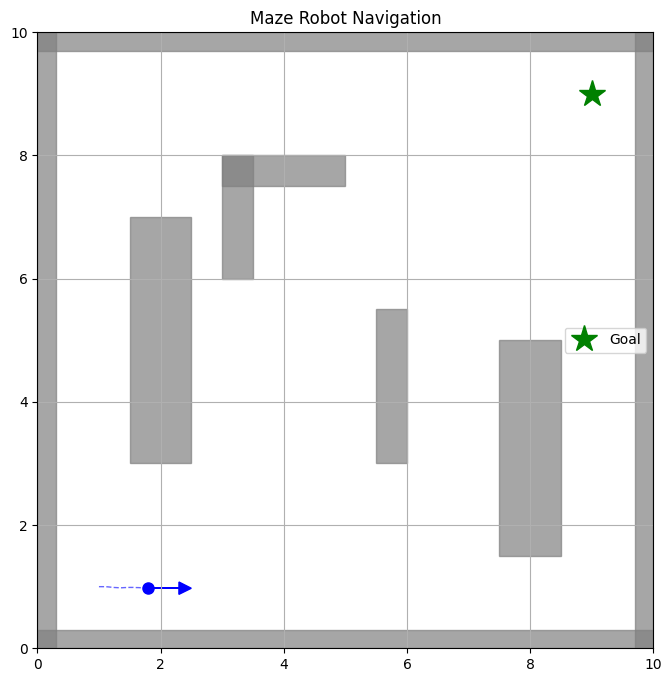

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arrow, Rectangle

class MazeRobotEnv(gym.Env):
    """
    2D differential drive robot in a maze with rectangular walls.
    State: [x, y, theta, rel_goal_x, rel_goal_y, lidar_readings (n_rays)]
    Action: [linear_vel, angular_vel]
    """

    def __init__(self, map_size=10.0, n_rays=8):
        super().__init__()
        self.map_size = map_size
        self.dt = 0.1
        self.n_rays = n_rays
        self.max_lidar_range = 5.0

        # Action space: linear velocity [0, 0.5], angular velocity [-1, 1]
        self.action_space = spaces.Box(
            low=np.array([0.0, -1.0], dtype=np.float32),
            high=np.array([0.5, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        # Observation space: [x, y, theta, rel_goal_x, rel_goal_y, lidar1..lidar_n]
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(3 + 2 + n_rays,), dtype=np.float32
        )

        self.robot_pos = None
        self.goal = None

        # Precompute ray angles (global frame, fixed)
        self.ray_angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False)

        # Build the maze walls
        self.walls = self._build_maze()

    def _build_maze(self):
        """Return a list of wall rectangles matching the user sketch."""
        walls = []
        s = self.map_size
        wall_thick = 0.3

        # Outer boundary (keep these to prevent the robot from leaving the map)
        walls.append({'xmin': 0, 'xmax': s, 'ymin': 0, 'ymax': wall_thick})           # bottom
        walls.append({'xmin': 0, 'xmax': s, 'ymin': s-wall_thick, 'ymax': s})         # top
        walls.append({'xmin': 0, 'xmax': wall_thick, 'ymin': 0, 'ymax': s})            # left
        walls.append({'xmin': s-wall_thick, 'xmax': s, 'ymin': 0, 'ymax': s})          # right

        # 1. L-shaped object (Top-Middle)
        walls.append({'xmin': 3.0, 'xmax': 3.5, 'ymin': 6.0, 'ymax': 8.0}) # L-vertical part
        walls.append({'xmin': 3.0, 'xmax': 5.0, 'ymin': 7.5, 'ymax': 8.0}) # L-horizontal part

        # 2. Left vertical pillar
        walls.append({'xmin': 1.5, 'xmax': 2.5, 'ymin': 3.0, 'ymax': 7.0})

        # 3. Middle-right vertical pillar
        walls.append({'xmin': 5.5, 'xmax': 6.0, 'ymin': 3.0, 'ymax': 5.5})

        # 4. Tall, thin pillar on the right
        walls.append({'xmin': 7.5, 'xmax': 8.5, 'ymin': 1.5, 'ymax': 5.0})

        return walls

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Robot starts bottom-left
        self.robot_pos = np.array([1.0, 1.0, 0.0], dtype=float)

        # Goal fixed at top-right
        self.goal = np.array([9.0, 9.0], dtype=float)

        return self._get_observation(), {}

    def step(self, action):
        v, omega = action
        # Kinematics
        theta = self.robot_pos[2]
        self.robot_pos[0] += v * np.cos(theta) * self.dt
        self.robot_pos[1] += v * np.sin(theta) * self.dt
        self.robot_pos[2] += omega * self.dt
        self.robot_pos[2] = np.arctan2(np.sin(self.robot_pos[2]), np.cos(self.robot_pos[2]))

        # Check termination
        collision = self._check_collision()
        reached_goal = np.linalg.norm(self.robot_pos[:2] - self.goal) < 0.5

        # Reward shaping
        dist_to_goal = np.linalg.norm(self.robot_pos[:2] - self.goal)
        reward = -0.1 * dist_to_goal + 0.5 * v - 0.1 * abs(omega)
        if reached_goal:
            reward += 100
        elif collision:
            reward -= 100

        terminated = reached_goal or collision
        truncated = False

        return self._get_observation(), reward, terminated, truncated, {
            'collision': collision,
            'reached_goal': reached_goal
        }

    def _get_observation(self):
        """Return state vector: [x, y, theta, rel_goal_x, rel_goal_y, lidar]"""
        # LiDAR readings
        lidar = [self._ray_cast_analytic(angle) for angle in self.ray_angles]

        # Relative goal in robot frame
        dx = self.goal[0] - self.robot_pos[0]
        dy = self.goal[1] - self.robot_pos[1]
        theta = self.robot_pos[2]
        rel_x = dx * np.cos(theta) + dy * np.sin(theta)
        rel_y = -dx * np.sin(theta) + dy * np.cos(theta)

        return np.concatenate([
            self.robot_pos,          # x, y, theta
            [rel_x, rel_y],          # relative goal
            np.array(lidar)          # LiDAR distances
        ]).astype(np.float32)

    def _ray_cast_analytic(self, angle):
        """Return distance to nearest wall along ray (global angle)."""
        ox, oy = self.robot_pos[0], self.robot_pos[1]
        dx = np.cos(angle)
        dy = np.sin(angle)
        min_dist = self.max_lidar_range

        for wall in self.walls:
            t_entry, _ = self._clip_ray_to_rect(ox, oy, dx, dy, wall)
            if t_entry > 1e-6 and t_entry < min_dist:
                min_dist = t_entry
        return min_dist

    def _clip_ray_to_rect(self, x0, y0, dx, dy, wall):
        """Liang-Barsky line clipping. Returns (t_entry, t_exit)."""
        xmin, xmax = wall['xmin'], wall['xmax']
        ymin, ymax = wall['ymin'], wall['ymax']
        t_entry = -np.inf
        t_exit = np.inf

        # X clipping
        if abs(dx) < 1e-12:
            if x0 < xmin or x0 > xmax:
                return np.inf, -np.inf
        else:
            t1 = (xmin - x0) / dx
            t2 = (xmax - x0) / dx
            if t1 > t2:
                t1, t2 = t2, t1
            t_entry = max(t_entry, t1)
            t_exit = min(t_exit, t2)
            if t_entry > t_exit:
                return np.inf, -np.inf

        # Y clipping
        if abs(dy) < 1e-12:
            if y0 < ymin or y0 > ymax:
                return np.inf, -np.inf
        else:
            t1 = (ymin - y0) / dy
            t2 = (ymax - y0) / dy
            if t1 > t2:
                t1, t2 = t2, t1
            t_entry = max(t_entry, t1)
            t_exit = min(t_exit, t2)
            if t_entry > t_exit:
                return np.inf, -np.inf

        return t_entry, t_exit

    def _check_collision(self):
        """Robot circle (radius 0.2) vs walls."""
        robot_radius = 0.2
        cx, cy = self.robot_pos[0], self.robot_pos[1]

        # Boundary check (redundant but safe)
        if not (0 <= cx <= self.map_size and 0 <= cy <= self.map_size):
            return True

        for wall in self.walls:
            closest_x = np.clip(cx, wall['xmin'], wall['xmax'])
            closest_y = np.clip(cy, wall['ymin'], wall['ymax'])
            if np.hypot(cx - closest_x, cy - closest_y) < robot_radius:
                return True
        return False

    def render(self, path=None):
        """Render the environment (static, called once)."""
        fig, ax = plt.subplots(figsize=(8, 8))
        self._draw_environment(ax)
        # Draw robot
        ax.plot(self.robot_pos[0], self.robot_pos[1], 'bo', markersize=8)
        ax.arrow(self.robot_pos[0], self.robot_pos[1],
                 0.5 * np.cos(self.robot_pos[2]),
                 0.5 * np.sin(self.robot_pos[2]),
                 head_width=0.2, head_length=0.2, fc='blue', ec='blue')
        if path is not None:
            ax.plot(path[:, 0], path[:, 1], 'b--', alpha=0.6, linewidth=1)
        plt.title("Maze Robot Navigation")
        plt.show()

    def _draw_environment(self, ax):
        """Draw static elements (walls, goal)."""
        ax.clear()
        for wall in self.walls:
            rect = Rectangle(
                (wall['xmin'], wall['ymin']),
                wall['xmax'] - wall['xmin'],
                wall['ymax'] - wall['ymin'],
                color='gray', alpha=0.7
            )
            ax.add_patch(rect)
        ax.plot(self.goal[0], self.goal[1], 'g*', markersize=20, label='Goal')
        ax.set_xlim(0, self.map_size)
        ax.set_ylim(0, self.map_size)
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend()


# ================== INTERACTIVE KEYBOARD CONTROL ==================
def interactive_control(env):
    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 8))
    env._draw_environment(ax)

    # Robot graphics
    robot_circle = Circle((env.robot_pos[0], env.robot_pos[1]), 0.2, color='blue', zorder=3)
    robot_arrow = Arrow(env.robot_pos[0], env.robot_pos[1], 0, 0, width=0.1, color='blue')
    ax.add_patch(robot_circle)
    ax.add_patch(robot_arrow)
    vel_text = ax.text(0.5, 0.95, "", transform=ax.transAxes, ha='center')

    linear_vel = 0.0
    angular_vel = 0.0

    def on_key(event):
        nonlocal linear_vel, angular_vel
        if event.key == 'up':
            linear_vel = min(0.5, linear_vel + 0.05)
        elif event.key == 'down':
            linear_vel = max(0.0, linear_vel - 0.05)
        elif event.key == 'left':
            angular_vel = max(-1.0, angular_vel - 0.1)
        elif event.key == 'right':
            angular_vel = min(1.0, angular_vel + 0.1)
        elif event.key == ' ':
            linear_vel = 0.0
            angular_vel = 0.0
        elif event.key == 'r':
            env.reset()
            env._draw_environment(ax)
            robot_circle.center = (env.robot_pos[0], env.robot_pos[1])
            robot_arrow.remove()
            robot_arrow = Arrow(env.robot_pos[0], env.robot_pos[1], 0, 0, width=0.1, color='blue')
            ax.add_patch(robot_arrow)
            fig.canvas.draw()
        elif event.key == 'q':
            plt.close(fig)
            return
        vel_text.set_text(f"lin={linear_vel:.2f}  ang={angular_vel:.2f}")
        fig.canvas.draw()

    fig.canvas.mpl_connect('key_press_event', on_key)
    print("Interactive control active. Use arrow keys, Space (stop), R (reset), Q (quit).")

    try:
        while plt.fignum_exists(fig.number):
            action = np.array([linear_vel, angular_vel], dtype=np.float32)
            obs, reward, terminated, truncated, info = env.step(action)
            robot_circle.center = (env.robot_pos[0], env.robot_pos[1])
            robot_arrow.remove()
            robot_arrow = Arrow(env.robot_pos[0], env.robot_pos[1],
                                0.5 * np.cos(env.robot_pos[2]),
                                0.5 * np.sin(env.robot_pos[2]),
                                width=0.1, color='blue')
            ax.add_patch(robot_arrow)
            if terminated:
                if info['reached_goal']:
                    print("🎉 Goal reached! Press R to reset or Q to quit.")
                elif info['collision']:
                    print("💥 Collision! Press R to reset or Q to quit.")
                linear_vel = 0.0
                angular_vel = 0.0
                vel_text.set_text("STOPPED")
            fig.canvas.draw()
            plt.pause(env.dt)
    except KeyboardInterrupt:
        pass
    plt.ioff()
    plt.close(fig)
    print("Interactive session ended.")


# ================== MAIN ==================
if __name__ == "__main__":
    print("Choose mode:")
    print("1. Test random actions (static render)")
    print("2. Interactive keyboard control (maze)")
    choice = input("Enter 1 or 2: ")

    if choice == "1":
        env = MazeRobotEnv(map_size=10.0, n_rays=8)
        obs, info = env.reset()
        print(f"✓ Observation shape: {obs.shape} (expected: 13)")
        trajectory = [env.robot_pos.copy()]
        for step in range(50):
            action = np.random.uniform([0, -0.5], [0.3, 0.5])
            obs, reward, terminated, truncated, info = env.step(action)
            trajectory.append(env.robot_pos.copy())
            if step % 10 == 0:
                print(f"Step {step}: pos=({env.robot_pos[0]:.2f}, {env.robot_pos[1]:.2f}), reward={reward:.2f}")
            if terminated:
                print(f"Done! Collision: {info['collision']}, Goal: {info['reached_goal']}")
                break
        env.render(path=np.array(trajectory))

    elif choice == "2":
        env = MazeRobotEnv(map_size=10.0, n_rays=4)   # fewer rays for speed
        env.reset()
        interactive_control(env)
    else:
        print("Invalid choice.")

Observation dimension: 13
Using device: cpu
Starting training (1000 episodes)...
Episode    1 | Reward: -151.59 | Epsilon: 1.000 | Success: 0/1 | Avg50: -151.59
Episode    2 | Reward: -263.95 | Epsilon: 0.991 | Success: 0/2 | Avg50: -263.95
Episode    3 | Reward: -225.30 | Epsilon: 0.981 | Success: 0/3 | Avg50: -225.30
Episode    4 | Reward: -254.81 | Epsilon: 0.966 | Success: 0/4 | Avg50: -254.81
Episode    5 | Reward: -253.44 | Epsilon: 0.951 | Success: 0/5 | Avg50: -253.44
Episode    6 | Reward: -268.59 | Epsilon: 0.939 | Success: 0/6 | Avg50: -268.59
Episode    7 | Reward: -266.48 | Epsilon: 0.926 | Success: 0/7 | Avg50: -266.48
Episode    8 | Reward: -264.94 | Epsilon: 0.914 | Success: 0/8 | Avg50: -264.94
Episode    9 | Reward: -274.29 | Epsilon: 0.898 | Success: 0/9 | Avg50: -274.29
Episode   10 | Reward: -153.04 | Epsilon: 0.896 | Success: 0/10 | Avg50: -153.04
Episode   11 | Reward: -173.83 | Epsilon: 0.892 | Success: 0/11 | Avg50: -173.83
Episode   12 | Reward: -264.97 | Epsi

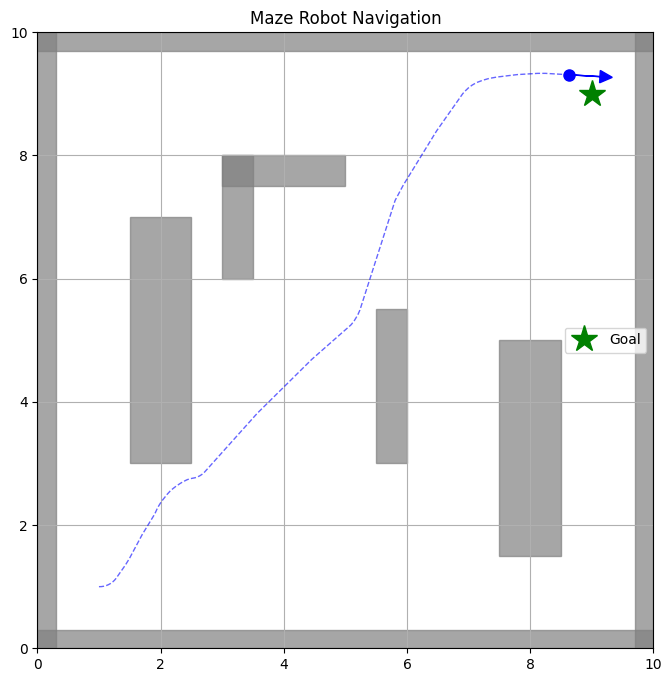

Test finished. Total reward: -65.77, Goal reached: True


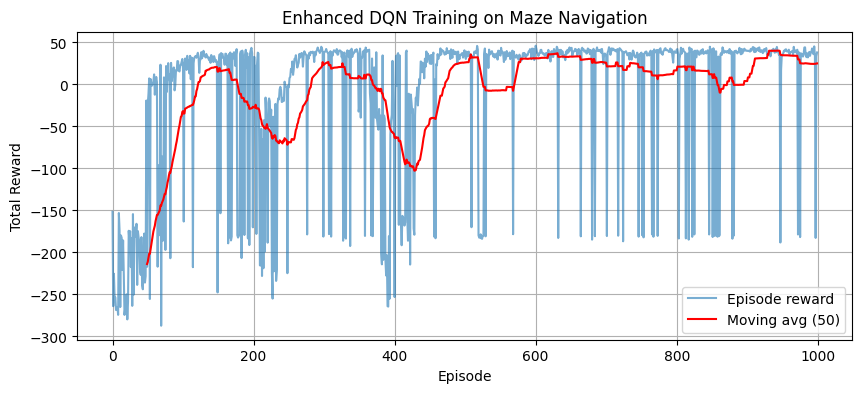

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import time

# Simplified action space: 0=forward, 1=turn left, 2=turn right
action_map = {
    0: np.array([0.35, 0.0], dtype=np.float32),   # forward faster
    1: np.array([0.2, 0.6], dtype=np.float32),    # turn left
    2: np.array([0.2, -0.6], dtype=np.float32)    # turn right
}
num_actions = len(action_map)

# Deep Q-Network (slightly larger)
class DQN(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_size=256):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_actions)
        )
    def forward(self, x):
        return self.net(x)

# Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=200000):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))
    def __len__(self):
        return len(self.buffer)

# DQN Agent with improved hyperparameters
class DQNAgent:
    def __init__(self, obs_dim, num_actions, learning_rate=1e-3, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=20000,
                 target_update_freq=200, batch_size=128, device='cpu'):
        self.num_actions = num_actions
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.target_update_freq = target_update_freq
        self.batch_size = batch_size
        self.device = device
        self.steps = 0

        self.q_network = DQN(obs_dim, num_actions).to(device)
        self.target_network = DQN(obs_dim, num_actions).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.replay_buffer = ReplayBuffer()

    def select_action(self, state):
        # Linear epsilon decay
        self.epsilon = max(self.epsilon_end,
                           self.epsilon_start - (self.epsilon_start - self.epsilon_end) * self.steps / self.epsilon_decay)
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return q_values.argmax().item()

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        current_q = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = nn.MSELoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to avoid exploding gradients
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

# Training function with improved reward calculation
def train_dqn(env, agent, num_episodes=1000, max_steps_per_episode=500, render_final=True):
    episode_rewards = []
    success_count = 0
    best_reward = -float('inf')

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        prev_distance = np.linalg.norm(env.robot_pos[:2] - env.goal)

        for step in range(max_steps_per_episode):
            action_idx = agent.select_action(state)
            continuous_action = action_map[action_idx]
            next_state, reward, terminated, truncated, info = env.step(continuous_action)

            # --- Improved reward shaping ---
            # 1. Distance delta: positive if getting closer to goal
            new_distance = np.linalg.norm(env.robot_pos[:2] - env.goal)
            distance_delta = prev_distance - new_distance
            shaped_reward = reward + 5.0 * distance_delta   # encourage moving toward goal

            # 2. Small survival reward (to avoid trivial collapse)
            if not terminated:
                shaped_reward += 0.1

            # 3. Penalise high angular velocity (smooth movement)
            shaped_reward -= 0.05 * abs(continuous_action[1])

            # 4. Extra penalty for staying still (linear_vel < 0.05)
            if continuous_action[0] < 0.05:
                shaped_reward -= 0.2

            agent.store_transition(state, action_idx, shaped_reward, next_state, terminated)
            agent.update()

            episode_reward += shaped_reward
            state = next_state
            prev_distance = new_distance

            if terminated:
                if info['reached_goal']:
                    success_count += 1
                break

        episode_rewards.append(episode_reward)
        avg_reward = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else episode_reward

        # Save best model
        if episode_reward > best_reward and episode > 100:
            best_reward = episode_reward
            torch.save(agent.q_network.state_dict(), 'best_dqn_maze.pth')

        print(f"Episode {episode+1:4d} | Reward: {episode_reward:7.2f} | "
              f"Epsilon: {agent.epsilon:.3f} | Success: {success_count}/{episode+1} | Avg50: {avg_reward:.2f}")

    # Load best model for testing
    agent.q_network.load_state_dict(torch.load('best_dqn_maze.pth'))

    # Test the trained agent
    if render_final:
        print("\n=== Testing trained agent (best model) ===")
        state, _ = env.reset()
        trajectory = [env.robot_pos[:2].copy()]
        done = False
        total_reward = 0
        while not done:
            action_idx = agent.select_action(state)   # exploitation
            continuous_action = action_map[action_idx]
            state, reward, terminated, truncated, info = env.step(continuous_action)
            total_reward += reward
            trajectory.append(env.robot_pos[:2].copy())
            done = terminated or truncated
            if done:
                env.render(path=np.array(trajectory))
                time.sleep(0.5)
        print(f"Test finished. Total reward: {total_reward:.2f}, Goal reached: {info['reached_goal']}")

    return episode_rewards

# Main execution
if __name__ == "__main__":
    # Create environment (must already be defined)
    env = MazeRobotEnv(map_size=10.0, n_rays=8)
    obs_dim = env.observation_space.shape[0]   # 13
    print(f"Observation dimension: {obs_dim}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    agent = DQNAgent(obs_dim, num_actions, learning_rate=1e-3, gamma=0.99,
                     epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=20000,
                     target_update_freq=200, batch_size=128, device=device)

    print("Starting training (1000 episodes)...")
    rewards_history = train_dqn(env, agent, num_episodes=1000, max_steps_per_episode=500, render_final=True)

    # Plot training curve
    plt.figure(figsize=(10, 4))
    plt.plot(rewards_history, alpha=0.6, label='Episode reward')
    window = 50
    if len(rewards_history) >= window:
        moving_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
        plt.plot(np.arange(window-1, len(rewards_history)), moving_avg, 'r', label='Moving avg (50)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Enhanced DQN Training on Maze Navigation')
    plt.legend()
    plt.grid(True)
    plt.show()